In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

PROJECT_ROOT = Path.cwd().parent
RAW = PROJECT_ROOT / "data" / "raw"
PROCESSED = PROJECT_ROOT / "data" / "processed"

orders = pd.read_csv(RAW / "olist_orders_dataset.csv")
customers = pd.read_csv(RAW / "olist_customers_dataset.csv")
items = pd.read_csv(RAW / "olist_order_items_dataset.csv")

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders = orders[orders["order_status"] == "delivered"].copy()

orders = orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

order_revenue = (
    items.groupby("order_id")
    .agg(
        order_value=("price", "sum"),
        freight_value=("freight_value", "sum"),
        items_count=("order_item_id", "count")
    )
    .reset_index()
)

order_revenue["total_value"] = (
    order_revenue["order_value"] +
    order_revenue["freight_value"]
)

orders = orders.merge(
    order_revenue,
    on="order_id",
    how="left"
)

print(orders.shape)

(96478, 13)


In [2]:
CUTOFF_DATE = pd.Timestamp("2018-03-01")
FUTURE_END = CUTOFF_DATE + pd.Timedelta(days=90)

print("Feature cutoff:", CUTOFF_DATE)
print("Future period ends:", FUTURE_END)

Feature cutoff: 2018-03-01 00:00:00
Future period ends: 2018-05-30 00:00:00


In [3]:
historical = orders[
    orders["order_purchase_timestamp"] < CUTOFF_DATE
].copy()

customer_history = (
    historical
    .groupby("customer_unique_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_spend=("total_value", "sum"),
        average_order_value=("total_value", "mean"),
        total_items=("items_count", "sum"),
        first_purchase=("order_purchase_timestamp", "min"),
        last_purchase=("order_purchase_timestamp", "max")
    )
    .reset_index()
)

customer_history["recency_days"] = (
    CUTOFF_DATE -
    customer_history["last_purchase"]
).dt.days

customer_history["customer_lifetime_days"] = (
    customer_history["last_purchase"] -
    customer_history["first_purchase"]
).dt.days

customer_history["purchase_frequency"] = (
    customer_history["total_orders"] /
    (customer_history["customer_lifetime_days"] + 1)
)

print(customer_history.shape)

(55525, 10)


In [4]:
future_orders = orders[
    (orders["order_purchase_timestamp"] >= CUTOFF_DATE) &
    (orders["order_purchase_timestamp"] < FUTURE_END)
].copy()

future_customers = set(
    future_orders["customer_unique_id"]
)

customer_history["churned"] = (
    ~customer_history["customer_unique_id"]
    .isin(future_customers)
).astype(int)

print(customer_history["churned"].value_counts())

churned
1    55139
0      386
Name: count, dtype: int64


In [5]:
features = [
    "total_orders",
    "total_spend",
    "average_order_value",
    "total_items",
    "recency_days",
    "customer_lifetime_days",
    "purchase_frequency"
]

X = customer_history[features]
y = customer_history["churned"]

print("Features:", features)
print("Customers:", len(X))

Features: ['total_orders', 'total_spend', 'average_order_value', 'total_items', 'recency_days', 'customer_lifetime_days', 'purchase_frequency']
Customers: 55525


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (44420, 7)
Testing: (11105, 7)


In [7]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

In [8]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [9]:
def evaluate_model(name, y_true, predictions, probabilities):
    print(f"\n{name}")
    print("-" * 40)
    print("Accuracy :", round(accuracy_score(y_true, predictions), 4))
    print("Precision:", round(precision_score(y_true, predictions), 4))
    print("Recall   :", round(recall_score(y_true, predictions), 4))
    print("F1 Score :", round(f1_score(y_true, predictions), 4))
    print("ROC-AUC  :", round(roc_auc_score(y_true, probabilities), 4))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, predictions))


evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_pred,
    logistic_prob
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)


Logistic Regression
----------------------------------------
Accuracy : 0.993
Precision: 0.9931
Recall   : 0.9999
F1 Score : 0.9965
ROC-AUC  : 0.5656

Confusion Matrix:
[[    0    77]
 [    1 11027]]

Random Forest
----------------------------------------
Accuracy : 0.8434
Precision: 0.9932
Recall   : 0.8481
F1 Score : 0.9149
ROC-AUC  : 0.5165

Confusion Matrix:
[[  13   64]
 [1675 9353]]


In [10]:
test_results = X_test.copy()

test_results["actual_churn"] = y_test.values
test_results["predicted_churn"] = rf_pred
test_results["churn_probability"] = rf_prob

test_results.to_csv(
    PROCESSED / "churn_predictions.csv",
    index=False
)

print("Saved churn predictions.")

Saved churn predictions.


In [11]:
import shap
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [12]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

print("SHAP values calculated.")

SHAP values calculated.


In [13]:
print(type(shap_values))

if isinstance(shap_values, list):
    print("Number of SHAP arrays:", len(shap_values))
    print("Shape of positive-class SHAP values:", shap_values[1].shape)
else:
    print("SHAP shape:", shap_values.shape)

<class 'numpy.ndarray'>
SHAP shape: (11105, 7, 2)


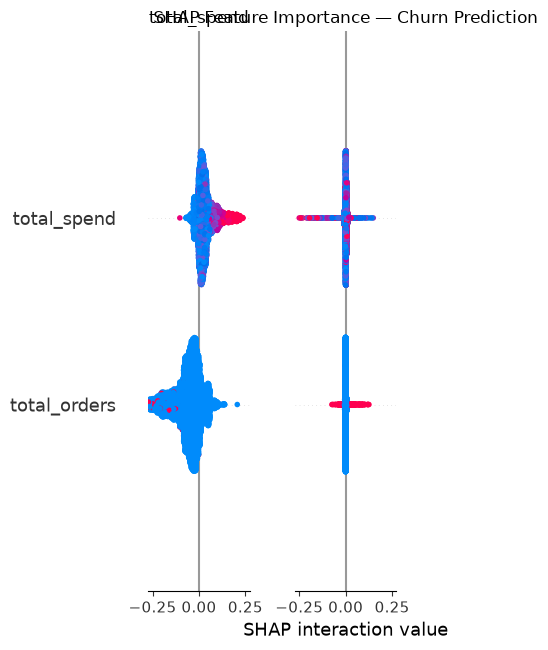

In [14]:
if isinstance(shap_values, list):
    shap.summary_plot(
        shap_values[1],
        X_test,
        show=False
    )
else:
    shap.summary_plot(
        shap_values,
        X_test,
        show=False
    )

plt.title("SHAP Feature Importance — Churn Prediction")
plt.tight_layout()
plt.show()

In [15]:
prediction_results = customer_history.loc[
    X_test.index,
    [
        "customer_unique_id",
        "total_orders",
        "total_spend",
        "average_order_value",
        "total_items",
        "recency_days",
        "customer_lifetime_days",
        "purchase_frequency",
        "churned"
    ]
].copy()

prediction_results["predicted_churn"] = rf_pred
prediction_results["churn_probability"] = rf_prob

prediction_results.head()

,customer_unique_id,total_orders,total_spend,average_order_value,total_items,recency_days,customer_lifetime_days,purchase_frequency,churned,predicted_churn,churn_probability
2087,09a2a3befff4ee3680617f07d9b473ed,1,99.70,99.70,1,277,0,1.0,1,0,0.490247
6447,1dbc5f3eb27b11b2b77a49c808c8bbc0,1,87.64,87.64,1,56,0,1.0,1,1,0.600496
21176,614dff8971a50ecca2de2edd11934796,1,93.30,93.30,1,157,0,1.0,1,1,0.662688
30195,8b8cb3fc3f7ae14192f65dff259381ee,1,180.52,180.52,2,61,0,1.0,1,1,0.809155
52404,f16ed8e2ddd5b798116612f2dcf3d523,1,36.78,36.78,1,206,0,1.0,1,1,0.655547


In [16]:
def assign_risk(probability):
    if probability >= 0.75:
        return "High Risk"
    elif probability >= 0.50:
        return "Medium Risk"
    else:
        return "Low Risk"


prediction_results["risk_category"] = (
    prediction_results["churn_probability"]
    .apply(assign_risk)
)

prediction_results["risk_category"].value_counts()

risk_category
Medium Risk    7023
High Risk      2394
Low Risk       1688
Name: count, dtype: int64

In [17]:
prediction_results["expected_revenue_at_risk"] = (
    prediction_results["average_order_value"] *
    prediction_results["churn_probability"]
)

prediction_results[
    [
        "customer_unique_id",
        "churn_probability",
        "average_order_value",
        "expected_revenue_at_risk"
    ]
].head()

,customer_unique_id,churn_probability,average_order_value,expected_revenue_at_risk
2087,09a2a3befff4ee3680617f07d9b473ed,0.490247,99.70,48.877589
6447,1dbc5f3eb27b11b2b77a49c808c8bbc0,0.600496,87.64,52.627458
21176,614dff8971a50ecca2de2edd11934796,0.662688,93.30,61.828778
30195,8b8cb3fc3f7ae14192f65dff259381ee,0.809155,180.52,146.068658
52404,f16ed8e2ddd5b798116612f2dcf3d523,0.655547,36.78,24.111015


In [18]:
total_revenue_at_risk = (
    prediction_results["expected_revenue_at_risk"].sum()
)

print(
    f"Estimated revenue at risk: "
    f"{total_revenue_at_risk:,.2f}"
)

Estimated revenue at risk: 1,266,386.36


In [19]:
prediction_results["retention_priority_score"] = (
    prediction_results["churn_probability"] *
    prediction_results["total_spend"]
)

In [20]:
priority_customers = prediction_results.sort_values(
    "retention_priority_score",
    ascending=False
)

priority_customers[
    [
        "customer_unique_id",
        "churn_probability",
        "total_spend",
        "expected_revenue_at_risk",
        "risk_category",
        "retention_priority_score"
    ]
].head(20)

,customer_unique_id,churn_probability,total_spend,expected_revenue_at_risk,risk_category,retention_priority_score
47943,dc4802a71eae9be1dd28f5d788ceb526,0.990737,6929.31,6865.126537,High Risk,6865.126537
55352,ff4159b92c40ebe40454e3e6a7c35ed6,0.984459,6726.66,6622.123944,High Risk,6622.123944
51699,edf81e1f3070b9dac83ec83dacdbb9bc,0.992315,4194.76,4162.521313,High Risk,4162.521313
20241,5d09b0d82126457e2a8ebfb9c9a1ffc4,0.990737,3736.22,3701.612869,High Risk,3701.612869
55304,ff0ae98646e7bbb41cf0f0d3991fef98,0.984415,3048.27,3000.762998,High Risk,3000.762998
24085,6f00d356a4be20527662aaf12116baab,0.925710,3184.55,2947.970586,High Risk,2947.970586
4303,13d9920a16127351540bcd95ad4643c8,0.995554,2733.63,2721.474945,High Risk,2721.474945
2995,0de97ff655abfc142ba6fc83e86bf082,0.972973,2734.66,2660.750332,High Risk,2660.750332
26059,7814db11654d2bf3b43bae828b6eee05,0.992315,2606.01,2585.981598,High Risk,2585.981598
51324,ec4b05ce75316354ba9b297f64377ed6,0.986629,2288.31,2257.713187,High Risk,2257.713187


In [21]:
prediction_results.to_csv(
    PROCESSED / "customer_churn_predictions.csv",
    index=False
)

print("Final churn prediction dataset saved.")

Final churn prediction dataset saved.
